In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from src.data_import import load_fashion_mnist
from src.sampler import ReplaySampler
from src.diagnostic import diagnose
from src.plot import show_grid, show_single_sample

In [3]:
train_loader, test_loader = load_fashion_mnist(32, shuffle=True, class_subset=[9])

In [4]:
class EnergyHead(nn.Module):
    def __init__(self, image_shape):
        super().__init__()
        c, w, h = image_shape if len(image_shape) == 3 else image_shape[1:]

        self.conv_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(c, 16, 3, padding=1)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Conv2d(16, 32, 4, stride=2, padding=1)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Conv2d(32, 64, 4, stride=2, padding=1)),
            nn.ReLU(),
            nn.Flatten(),
        )

        flat_dim = 64 * (w // 4) * (h // 4)

        self.linear = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(flat_dim, 7 * 7)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(7 * 7, 1))
        )

    def forward(self, x):
        return self.linear(self.conv_net(x))  # [B, 1]
    
    
class EBM(nn.Module):

    def __init__(self, image_shape: tuple, mid_dim: int, n_classes: int,
                 n_heads: int = 4, batch_size: int = 32) -> None:
        super().__init__()
        self.n_heads = n_heads
        self.n_classes = n_classes

        self.heads = nn.ModuleList(
            [EnergyHead(image_shape) for _ in range(n_heads)]
        )
        self.head_outputs = torch.empty(batch_size, n_heads, requires_grad=False)

        self.combiner = nn.Linear(n_heads + n_classes, 1, bias=True)

    def forward(self, x, class_idx=None):

        h_o = torch.stack([head(x).squeeze(-1) for head in self.heads], dim=1)  # [B, K]
        self.head_outputs = h_o.detach()

        if class_idx is not None:
            c = F.one_hot(class_idx, num_classes=self.n_classes).float()  # [B, n_classes]
        else:
            c = torch.zeros(x.size(0), self.n_classes, device=x.device)

        combined = torch.cat([h_o, c], dim=1)           # [B, K + n_classes]
        energy   = self.combiner(combined).squeeze(-1)   # [B]

        return energy, h_o


In [5]:
model = EBM(image_shape=(1,28,28), mid_dim=150, n_heads=4, batch_size=32, n_classes=10)
model.to(device)
model.load_state_dict(torch.load("./conditional/ebm_fmnist_4heads_150mid_conditional.pth", map_location=device))
model.to(device)
model.eval()

sampler = ReplaySampler(model, img_shape=(1, 28, 28), buffer_size=200, noise_fraction=0.05, device=device)


In [6]:
real_samples = torch.cat([x for x, _ in test_loader], dim=0)
real_samples.shape

torch.Size([1000, 1, 28, 28])

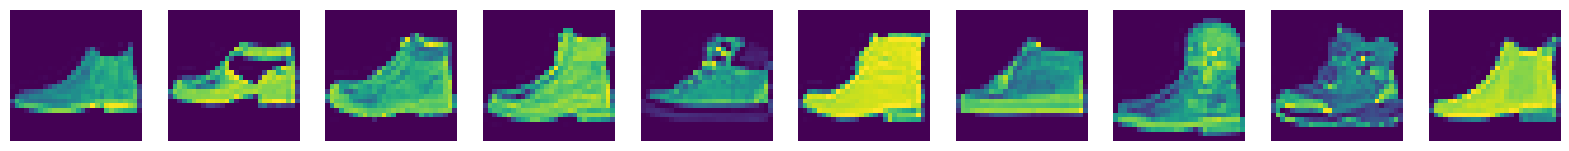

In [9]:
show_grid(real_samples, n = 10)

In [10]:
from torchmetrics.image.fid import FrechetInceptionDistance
import torch

def evaluate_sampling_fid(real_images: torch.Tensor, fake_images: torch.Tensor):

    fid = FrechetInceptionDistance(feature=2048)

    real_images = real_images.repeat(1, 3, 1, 1)
    fake_images = fake_images.repeat(1, 3, 1, 1)

    real_images = (real_images * 255).clamp(0, 255).to(torch.uint8)
    fake_images = ((fake_images + 1) * 127.5).clamp(0, 255).to(torch.uint8)

    batch_size = 64

    with torch.inference_mode():
        for i in range(0, len(real_images), batch_size):
            fid.update(real_images[i:i+batch_size], real=True)

        for i in range(0, len(fake_images), batch_size):
            fid.update(fake_images[i:i+batch_size], real=False)

    score = fid.compute()
    print("FID:", score.item())

evaluate_sampling_fid(real_samples, samples)

ModuleNotFoundError: No module named 'torchmetrics'

In [ ]:
diagnose(model, sampler, train_loader, test_loader, device=device, n_samples=16)

In [11]:

# ── 3. Visualizza gradienti per testa ────────────────────────────────────────

def visualize_head_gradients(model, x, device, idx=0):
    """
    Per una singola immagine, mostra dE_i/dx per ogni testa.
    Rivela cosa "guarda" ogni testa nell'immagine.
    """
    model.eval()
    img = x[idx].unsqueeze(0).to(device)  # (1, 1, 28, 28)

    n_heads = len(model.heads)
    fig, axes = plt.subplots(1, n_heads + 1, figsize=(3 * (n_heads + 1), 3))

    # Immagine originale
    axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    for i, head in enumerate(model.heads):
        x_ = img.detach().requires_grad_(True)
        with torch.enable_grad():
            e = head(x_).sum()
            g = torch.autograd.grad(e, x_, only_inputs=True)[0]

        g_np = g.squeeze().cpu().detach().numpy()
        g_np = np.abs(g_np)
        g_np = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

        axes[i + 1].imshow(g_np, cmap="hot")
        axes[i + 1].set_title(f"Head {i}\n|dE/dx|")
        axes[i + 1].axis("off")

    plt.suptitle("Gradient maps per testa", fontsize=12)
    plt.tight_layout()
    plt.show()


# ── 4. Matrice di correlazione tra teste ─────────────────────────────────────

def plot_head_correlation(model, loader, device, n_batches=10):
    """
    Plotta la matrice di correlazione tra gli output delle teste
    su n_batches di dati reali.
    """
    model.eval()
    all_h = []

    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= n_batches:
                break
            _, h = model(x.to(device))
            all_h.append(h.cpu())

    H = torch.cat(all_h, dim=0)  # (N, n_heads)
    H = H - H.mean(dim=0, keepdim=True)
    H = H / (H.std(dim=0, keepdim=True) + 1e-8)
    corr = (H.T @ H / (H.shape[0] - 1)).numpy()

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)

    n = corr.shape[0]
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=10)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f"Head {i}" for i in range(n)])
    ax.set_yticklabels([f"Head {i}" for i in range(n)])
    ax.set_title("Correlazione output tra teste")
    plt.tight_layout()
    plt.show()

    print("\nMatrice di correlazione:")
    print(np.round(corr, 3))
    return corr


# ── 5. Energia per testa su un batch ─────────────────────────────────────────

def plot_head_energies(model, x, device):
    """
    Boxplot dell'energia assegnata da ogni testa su un batch.
    """
    model.eval()
    with torch.no_grad():
        _, h = model(x.to(device))  # (B, n_heads)
    h = h.cpu().numpy()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(
        [h[:, i] for i in range(h.shape[1])],
        labels=[f"Head {i}" for i in range(h.shape[1])]
    )
    ax.set_ylabel("Energia")
    ax.set_title("Distribuzione energia per testa")
    plt.tight_layout()
    plt.show()

    print(f"\n{'Head':<10} {'mean':>8} {'std':>8}")
    print("-" * 28)
    for i in range(h.shape[1]):
        print(f"Head {i:<5} {h[:,i].mean():>8.4f} {h[:,i].std():>8.4f}")

In [ ]:
it = iter(test_loader)
for _ in range(10):
    next(it)

visualize_head_gradients(
    model, next(it)[0], device, idx=16
)

SyntaxError: incomplete input (1200240464.py, line 5)

In [42]:
tem, _ = load_fashion_mnist(batch_size=32, shuffle=True, class_subset=[4])

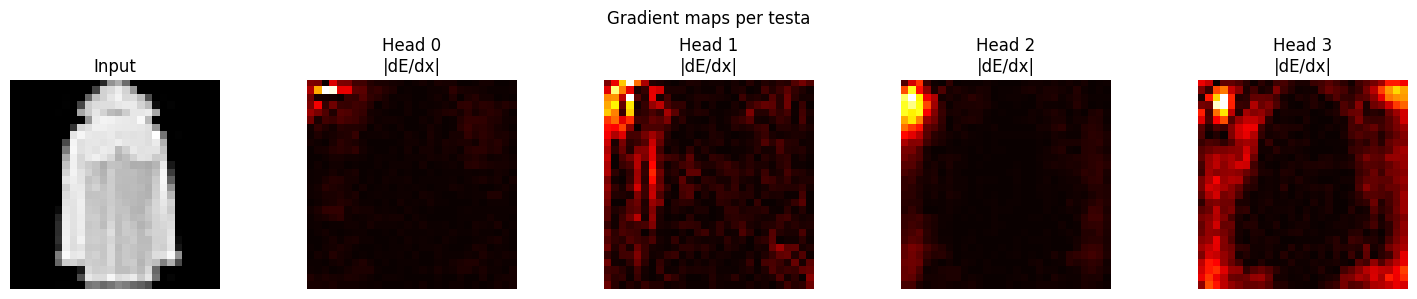

In [44]:
x_batch, _ = next(iter(tem))

# Gradienti visivi per la prima immagine del batch
visualize_head_gradients(model, x_batch, device, idx=0)